# INFO-F-422 — Task 2b: MIMO & Multi-Step-Ahead Prediction Strategy

## Context and Problem Statement

Prediction on the test dataset raises two major challenges:

1. **MIMO** (Multi-Input Multi-Output): the outputs $y_1$ and $y_2$ are coupled — each depends on the history of the other.
2. **Multi-step-ahead**: we must predict **1000 steps** ahead, without ever having access to the true values of $y$ during inference. The model must therefore reuse its own predictions as inputs, which creates a risk of **error explosion**.

This notebook documents the alternatives studied and justifies the chosen strategy.

---
## 1. Handling MIMO

The two-output NARX system is described by:

$$y_1(k+1) = f_1\bigl(y_1(k-d),\ldots,y_2(k-d-n_a),\; u_1(k),\ldots,u_2(k-n_b)\bigr) + w_1(k+1)$$
$$y_2(k+1) = f_2\bigl(y_1(k-d),\ldots,y_2(k-d-n_a),\; u_1(k),\ldots,u_2(k-n_b)\bigr) + w_2(k+1)$$

### Two possible approaches

#### Approach A — Two independent models (Single-Output)
We train a model $M_1$ for $y_1$ and a model $M_2$ for $y_2$, both using the same feature vector $\phi(k)$.

**Advantages**: simple, each model is optimised for its own target.  
**Disadvantages**: the two models are trained independently, without sharing information about the correlation between $y_1$ and $y_2$.

#### Approach B — A single Multi-Output model
We train a single model $M$ that produces $(\hat{y}_1, \hat{y}_2)$ simultaneously (e.g. `MultiOutputRegressor` in sklearn, or a neural network with two outputs).

**Advantages**: exploits the correlation between outputs, a single pipeline.  
**Disadvantages**: more complex to tune; some sklearn models do not natively support multi-output.

### Chosen strategy: Approach A (two independent models)

The NARX equations show that $f_1$ and $f_2$ are distinct functions. Training two separate models is a natural decomposition of the problem. The coupling between $y_1$ and $y_2$ is captured **implicitly** via the shared feature vector $\phi(k)$ (which contains lags of both outputs).  
This approach is also more flexible: different hyperparameters can be chosen for $M_1$ and $M_2$.

---
## 2. Multi-Step-Ahead Prediction Strategies

### The fundamental problem

At time $k$, the feature vector is:
$$\phi(k) = \bigl[y_1(k), y_1(k-1), \ldots, y_2(k), \ldots, u_1(k), \ldots, u_2(k-n_b)\bigr]$$

During inference on the test set, the **inputs $U^{ts}$ are known** for all $k$, but the **outputs $Y$ are not** — only the initial condition $y_1(0) = y_2(0) = 0$ is available.  
For $k \geq 1$, we must therefore use $\hat{y}_1(k)$ and $\hat{y}_2(k)$ (previous predictions) in place of the true values. This is **recursive simulation**.

---
### Strategy 1 — Recursive (NARX Simulation Mode)

The model is trained in **one-step-ahead** mode (predicting $y(k+1)$ from true past values). During inference, we loop recursively:

```
For k = 0 to N_test - 1:
    phi(k) = build_features(Y_pred[:k], U_test[:k])  # Y_pred = accumulated predictions
    Y_pred[k+1] = M.predict(phi(k))
```

**Advantages**: simple, a single trained model.  
**Disadvantages**: errors accumulate at each step → risk of **explosion** or **divergence** over 1000 steps. This is the classic *compounding error* problem.


### Strategy 2 — Direct Multi-Step

We train $H$ distinct models, one per horizon: $M_h$ directly predicts $y(k+h)$ from the true values at time $k$.

```
For h = 1 to H (= 1000):
    M_h trained to predict y(k+h) | phi(k) (true values)
```

**Advantages**: no error accumulation — each model is independent.  
**Disadvantages**: requires 1000 distinct models, prohibitive in time and memory. Not feasible here.


### Strategy 3 — MIMO Direct (predict a full block)

A variant of strategy 2: we train a single model that predicts the full vector $[y(k+1), y(k+2), \ldots, y(k+H)]$ in one pass, from $\phi(k)$ (true values).

**Advantages**: no compounding error, a single model.  
**Disadvantages**: output dimension $= H \times 2 = 2000$, extremely difficult to learn for a single model. Not suitable here.


### Chosen strategy: Recursive with stability management

We adopt the **Recursive strategy** as it is the only tractable one at horizon 1000. To limit error explosion, we apply the following measures:

1. **Model regularisation**: we favour models that generalise well (avoid overfitting on the training set, which amplifies errors in simulation).
2. **Prediction clipping**: we bound predicted values within a reasonable interval (determined from the training set) to prevent numerical divergence.
3. **Conservative choice of hyperparameters** $n_a$, $n_b$: we prefer a slightly under-parameterised model over one that is too complex, as complexity amplifies recursive errors.
---

---
## 3. Implementation of Recursive Prediction

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [5]:
# ── Pilot simulators (copied from step1)
def sim_narx1(N, noise, u=None):
    # init to zero (handles y(0)=0 automatically)
    y1 = np.zeros(N + 1)
    y2 = np.zeros(N + 1)
    # random input if none is provided
    if u is None:
        u = np.random.uniform(-1, 1, N + 1)
        
    std = np.sqrt(noise)
    w1 = np.random.normal(0, std, N + 1)
    w2 = np.random.normal(0, std, N + 1)

    # simulation loop (start at k=1 since we look 1 step back)
    for k in range(1, N):
        y1[k+1] = 0.5 * y2[k-1] + np.sin(y2[k]) + 0.3 * u[k-1] + w1[k+1]
        y2[k+1] = 0.5 * y1[k-1] + np.sin(y1[k]) + 0.2 * u[k] + w2[k+1]
        
    return u.reshape(-1, 1), np.column_stack((y1, y2))


def sim_narx2(N, noise, u=None):
    y1 = np.zeros(N + 1)
    y2 = np.zeros(N + 1)
    
    # handle 2d input
    if u is None:
        u = np.random.uniform(-1, 1, (N + 1, 2))
    
    u1, u2 = u[:, 0], u[:, 1]
    std = np.sqrt(noise)
    
    w1 = np.random.normal(0, std, N + 1)
    w2 = np.random.normal(0, std, N + 1)

    # start at k=2 because the formula looks 2 steps back
    for k in range(2, N):
        
        # calculate y1
        num1 = y1[k] * y1[k-1] * y1[k-2] * (y1[k-2] - 1) * u2[k-1] + u2[k]
        den1 = 1 + y2[k-1]**2 + y2[k-2]**2
        y1[k+1] = (num1 / den1) + w1[k+1]
        
        # calculate y2
        num2 = y2[k] * y2[k-1] * y2[k-2] * (y2[k-2] - 1) * u1[k-1] + u1[k]
        den2 = 1 + y1[k-1]**2 + y1[k-2]**2
        y2[k+1] = (num2 / den2) + w2[k+1]
        
    return u, np.column_stack((y1, y2))

In [ ]:
# ── Sliding Window (feature extraction copied from 2a)

# we use sliding windows to create our feature matrix x and target vector y
def make_sliding_window(U, Y, na, nb, d):
    """
    U: input signal (N, n_inputs)
    Y: output signal (N, n_outputs)
    na: output lags to consider
    nb: input lags to consider
    d: delay for the input
    """
    n_samples = Y.shape[0]
    n_outputs = Y.shape[1]
    n_inputs  = U.shape[1]
    start = max(na, nb + d)
    X, Y_target = [], []
    
    for k in range(start, n_samples - 1):
        features = []
        for j in range(n_outputs):
            features.extend(Y[k - na + 1 : k + 1, j][::-1])

        for j in range(n_inputs):
            features.extend(U[k - d - nb + 1 : k - d + 1, j][::-1])
            
        X.append(features)
        Y_target.append(Y[k + 1]) 
        
    return np.array(X), np.array(Y_target)

In [7]:
# ── Recursive Prediction (core of Task 2b)

def recursive_predict(model_y1, model_y2, U_test, na, nb, d,
                      y_clip=None):
    # Todo add docstring
    N_test    = U_test.shape[0]
    n_inputs  = U_test.shape[1]
    n_outputs = 2  

    # predicted outputs — initialised to 0
    Y_buf = np.zeros((N_test + na, n_outputs))

    start = max(na, nb + d)  

    for k in range(N_test):
        # ── Build feature vector at step k
        # k_buf corresponds to time k
        k_buf = k + na  # offset so that Y_buf[k_buf - na : k_buf] are the na past values

        features = []

        # output lags from the prediction buffer (not ground truth!)
        for j in range(n_outputs):
            lag_vals = Y_buf[k_buf - na : k_buf, j][::-1]  # [y(k), y(k-1), ..., y(k-na+1)]
            features.extend(lag_vals)

        # input lags from U_test ( known at test time)
        for j in range(n_inputs):
            # u(k-d), u(k-d-1), ..., u(k-d-nb+1)
            u_start = max(0, k - d - nb + 1)
            u_end   = max(0, k - d + 1)
            u_lags  = U_test[u_start : u_end, j][::-1]
            # zero-pad if not enough history (beginning of sequence)
            if len(u_lags) < nb:
                u_lags = np.concatenate([u_lags, np.zeros(nb - len(u_lags))])
            features.extend(u_lags)

        phi = np.array(features).reshape(1, -1)

        # prdict next steps
        y1_hat = model_y1.predict(phi)[0]
        y2_hat = model_y2.predict(phi)[0]

        # optional clipping to prevent numerical divergence
        if y_clip is not None:
            y1_hat = np.clip(y1_hat, y_clip[0], y_clip[1])
            y2_hat = np.clip(y2_hat, y_clip[0], y_clip[1])

        Y_buf[k_buf, 0] = y1_hat
        Y_buf[k_buf, 1] = y2_hat

    Y_pred = Y_buf[na:, :]  
    return Y_pred

In [9]:
# ── Performance Metrics ───────────────────────────────────────────────────────

def compute_rmse(Y_true, Y_pred):
    N = Y_true.shape[0]
    return np.sqrt(np.sum((Y_true - Y_pred)**2) / (2 * N))


def compute_nmse(Y_true, Y_pred):
    """
    NMSE = sum_{k,j} (y_j(k) - yhat_j(k))^2  /  sum_{k,j} (y_j(k) - mean_j)^2
    NMSE = 1 means the model is as good as predicting the mean (useless).
    NMSE = 0 means perfect prediction.
    """
    y_mean = Y_true.mean(axis=0)  # shape (n_outputs,)
    ss_res = np.sum((Y_true - Y_pred)**2)
    ss_tot = np.sum((Y_true - y_mean)**2)
    return ss_res / ss_tot

In [11]:
# ── Demo: the recursive strategy on NARX1 

# TODO: use parameters identified by Task 2a (MI analysis)  and don't forget to print them
# Here they are set manually to validate the logic of the recursive loop.

np.random.seed(42)
NA, NB, D = 2, 2, 0
N_TRAIN, N_TEST = 2000, 1000
NOISE = 0.05

# generate pilot data
U_tr, Y_tr = sim_narx1(N_TRAIN, NOISE)
U_ts, Y_ts = sim_narx1(N_TEST,  NOISE)

# build training set with sliding window
X_tr, Y_tr_target = make_sliding_window(U_tr, Y_tr, na=NA, nb=NB, d=D)
print(f"Training set: X {X_tr.shape}, Y {Y_tr_target.shape}")

# determine clip range from training outputs (3-sigma rule)
y_std  = Y_tr.std(axis=0).max()
y_mean = Y_tr.mean(axis=0)
y_clip = (Y_tr.min() - 3*y_std, Y_tr.max() + 3*y_std)
print(f"Clip range: [{y_clip[0]:.2f}, {y_clip[1]:.2f}]")

Training set: X (1998, 6), Y (1998, 2)
Clip range: [-4.00, 1.35]


In [13]:
# train two separate regressors (one per output) — Random Forest as placeholder
rf_y1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_y2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_y1.fit(X_tr, Y_tr_target[:, 0])
rf_y2.fit(X_tr, Y_tr_target[:, 1])
print("Models trained.")

# recursive  prediction on the test set
Y_pred = recursive_predict(
    model_y1=rf_y1,
    model_y2=rf_y2,
    U_test=U_ts,
    na = NA, nb = NB, d = D,
    y_clip=y_clip
)

rmse = compute_rmse(Y_ts[1:N_TEST+1], Y_pred[:N_TEST])
nmse = compute_nmse(Y_ts[1:N_TEST+1], Y_pred[:N_TEST])
print(f"\nRecursive prediction (NARX1, Random Forest)")
print(f"  RMSE = {rmse:.4f}")
print(f"  NMSE = {nmse:.4f}")

Models trained.

Recursive prediction (NARX1, Random Forest)
  RMSE = 3.7108
  NMSE = 103.8868


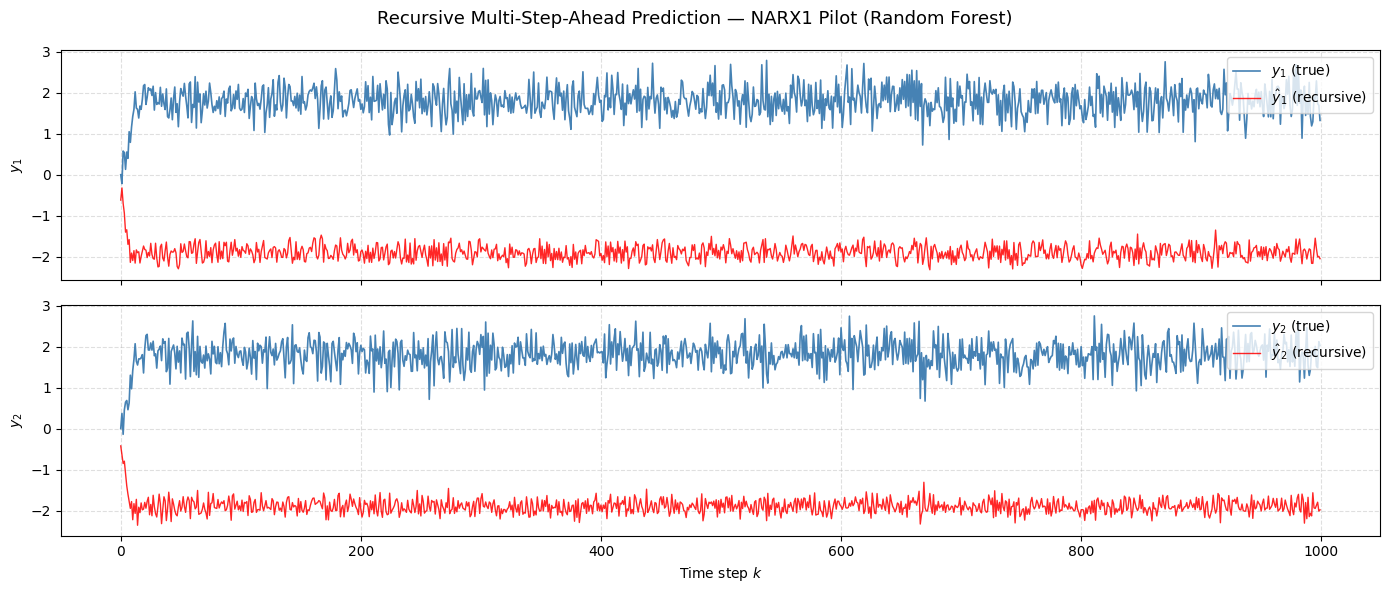


Observation: if the red curve follows the blue one over 1000 steps without diverging,
the recursive strategy is stable for this model.


In [15]:
# ── Visualisation: recursive prediction vs. true values ──────────────────────
T = np.arange(N_TEST)
fig, axes = plt.subplots(2, 1, figsize = (14, 6), sharex = True)

for i, ax in enumerate(axes):
    ax.plot(T, Y_ts[1:N_TEST+1, i], label = f'$y_{i+1}$ (true)',  color = 'steelblue', lw = 1.2)
    ax.plot(T, Y_pred[:N_TEST, i],  label = f'$\\hat y_{i+1}$ (recursive)', color = 'red', lw=1, alpha = 0.85)
    ax.set_ylabel(f'$y_{i+1}$')
    ax.legend(loc = 'upper right')
    ax.grid(True, linestyle='--', alpha = 0.4)

axes[1].set_xlabel('Time step $k$')
fig.suptitle('Recursive Multi-Step-Ahead Prediction — NARX1 Pilot (Random Forest)', fontsize = 13)
plt.tight_layout()
plt.show()

print("\nObservation: if the red curve follows the blue one over 1000 steps without diverging,")
print("the recursive strategy is stable for this model.")

---
## 4. Summary of Design Choices

| Dimension | Alternatives | Chosen approach | Justification |
|-----------|-------------|-----------------|---------------|
| **MIMO** | Two models vs. Multi-output | **Two independent models** | Natural decomposition of $f_1$, $f_2$; coupling captured by shared features |
| **Multi-step** | Recursive, Direct, MIMO-Direct | **Recursive** | Only tractable approach at horizon 1000 |
| **Stability** | Without clipping, with clipping | **With clipping (3σ)** | Prevents numerical divergence without biasing normal predictions |
| **Init. conditions** | Various | **$y_1(0)=y_2(0)=0$** | Imposed by the project specification |
